# Robust Text Sequence Recognition from Distorted Grayscale Images

This notebook implements a complete custom deep learning solution for distorted grayscale text sequence recognition. The solution uses a Convolutional Recurrent Neural Network built from scratch, combining CNN layers, Bidirectional LSTM layers, and CTC loss.

No pretrained model is used.

## Project Overview

Modern text recognition systems often fail when characters are noisy, overlapping, blurred, deformed, partially occluded, or irregularly spaced. This project addresses that problem by training a custom deep learning model to reconstruct the correct ordered character sequence from distorted grayscale images.

The solution is designed for the required submission format: a single reproducible notebook and a CSV file containing image filenames with predicted text sequences.

## Requirement Coverage

This notebook covers the complete workflow required for submission:

- problem understanding and objective
- dataset loading and visual inspection
- label distribution and character vocabulary analysis
- image preprocessing and augmentation
- custom CNN + Bidirectional LSTM architecture built from scratch
- CTC loss training without character-level bounding boxes
- validation using Character Error Rate
- train-validation overlap check
- exact match accuracy for additional validation insight
- final test prediction and submission CSV generation

## Pipeline

1. Mount Google Drive and set project paths.
2. Extract the dataset zip.
3. Load and inspect labels/images.
4. Define CER metric.
5. Define preprocessing and dataset classes.
6. Define the custom CNN + BiLSTM CRNN architecture.
7. Train with CTC loss.
8. Validate using CER and exact match accuracy.
9. Generate `submission_navya_24119034.csv`.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import sys

PROJECT_DIR = Path("/content/drive/MyDrive/Cig_Ai_open_project")
sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = Path("/content/data/cig_ps")
OUTPUT_DIR = PROJECT_DIR / "outputs"
TRAIN_IMAGE_DIR = DATA_DIR / "train_images"
TEST_IMAGE_DIR = DATA_DIR / "test_images"
CHECKPOINT_PATH = OUTPUT_DIR / "checkpoints" / "best.pt"
SUBMISSION_PATH = OUTPUT_DIR / "submission_navya_24119034.csv"

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /content/drive/MyDrive/Cig_Ai_open_project
Dataset directory: /content/data/cig_ps
Output directory: /content/drive/MyDrive/Cig_Ai_open_project/outputs


## Dataset Extraction

The dataset zip is stored in Google Drive. It is extracted into Colab temporary storage, while model checkpoints and the final CSV are saved to Google Drive.

In [ ]:
import zipfile

zip_path = PROJECT_DIR / "cig_ps.zip"

if not DATA_DIR.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(Path("/content/data"))

print("Dataset exists:", DATA_DIR.exists())
print("Dataset contents:", [p.name for p in DATA_DIR.iterdir()])

Dataset exists: True
Dataset contents: ['train_images', 'train-labels.csv', 'test_images']


In [ ]:
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFilter
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Load Training Labels

The label file contains the image name and corresponding text sequence. Only the required columns are kept.

In [ ]:
records = pd.read_csv(DATA_DIR / "train-labels.csv")
records = records[["image", "text"]].rename(columns={"text": "label"})
records["image"] = records["image"].astype(str)
records["label"] = records["label"].astype(str)

test_images = sorted(TEST_IMAGE_DIR.glob("*.png"))

print("Training records:", len(records))
print("Training images:", len(list(TRAIN_IMAGE_DIR.glob("*.png"))))
print("Test images:", len(test_images))
records.head()

Training records: 20000
Training images: 20000
Test images: 5000


,image,label
0,train-0.png,BU522X
1,train-1.png,XQ8NE2
2,train-2.png,DTZD3E
3,train-3.png,SM424H
4,train-4.png,6YVTQR


## Data Analysis

The observed alphabet and label length distribution are used to create the model output vocabulary.

count    20000.000000
mean         6.000250
std          0.025495
min          6.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          9.000000
Name: length, dtype: float64
Observed alphabet: +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar
Number of observed characters: 38


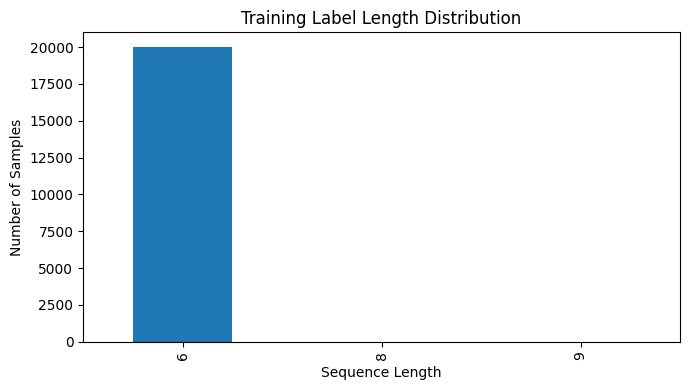

In [ ]:
records["length"] = records["label"].str.len()
observed_alphabet = "".join(sorted(set("".join(records["label"]))))

print(records["length"].describe())
print("Observed alphabet:", observed_alphabet)
print("Number of observed characters:", len(observed_alphabet))

fig, ax = plt.subplots(figsize=(7, 4))
records["length"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Training Label Length Distribution")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Number of Samples")
plt.tight_layout()

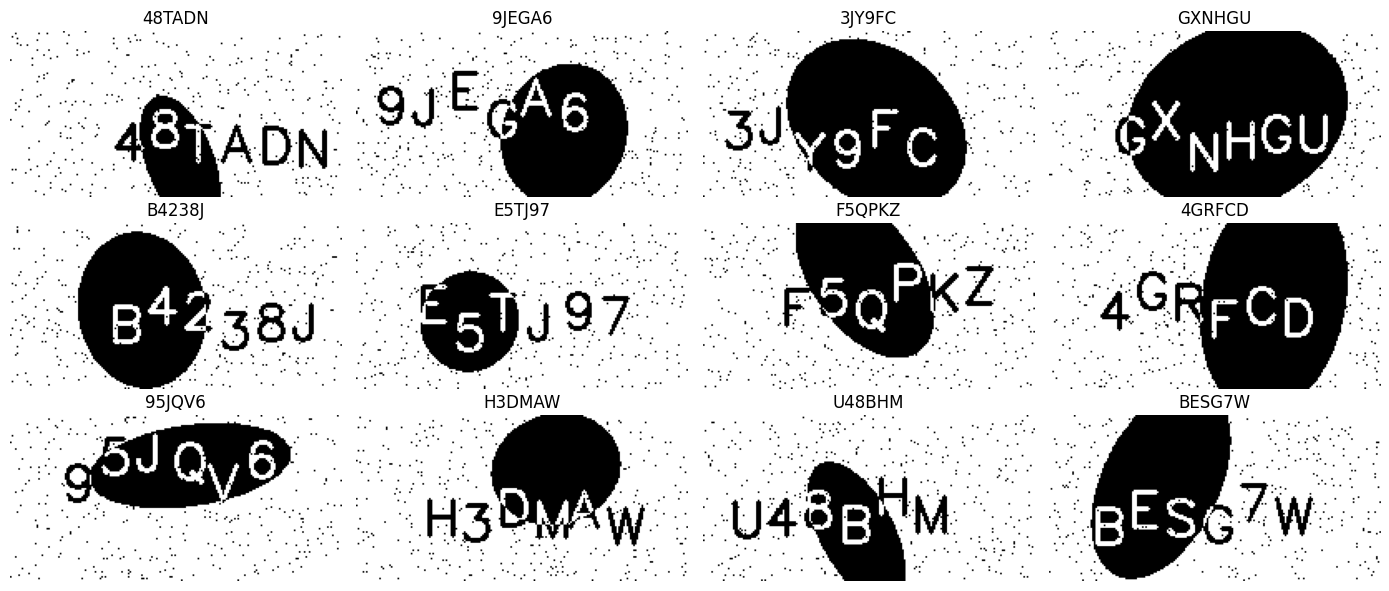

In [ ]:
sample = records.sample(12, random_state=42)
fig, axes = plt.subplots(3, 4, figsize=(14, 6))

for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
    img = Image.open(TRAIN_IMAGE_DIR / row.image).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(row.label)
    ax.axis("off")

plt.tight_layout()

## Character Error Rate

Character Error Rate is based on Levenshtein edit distance. It measures character-level mistakes, so a low CER may still include several samples with one-character errors.

In [ ]:
def levenshtein(a, b):
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a

    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i]
        for j, cb in enumerate(b, start=1):
            insert = current[j - 1] + 1
            delete = previous[j] + 1
            replace = previous[j - 1] + (ca != cb)
            current.append(min(insert, delete, replace))
        previous = current
    return previous[-1]


def character_error_rate(predictions, targets):
    total_distance = 0
    total_chars = 0
    for pred, target in zip(predictions, targets):
        total_distance += levenshtein(pred, target)
        total_chars += max(1, len(target))
    return total_distance / total_chars

## Hyperparameters

The validation split is 20 percent. The input size is `64 x 256`, and the model is trained from scratch using AdamW and CTC loss.

In [ ]:
@dataclass
class TrainConfig:
    img_height: int = 64
    img_width: int = 320
    batch_size: int = 64
    epochs: int = 15
    lr: float = 5e-4
    weight_decay: float = 1e-4
    val_split: float = 0.2
    seed: int = 42
    num_workers: int = 2
    patience: int = 8
    alphabet: str = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


config = TrainConfig()
config

TrainConfig(img_height=64, img_width=320, batch_size=64, epochs=15, lr=0.0005, weight_decay=0.0001, val_split=0.2, seed=42, num_workers=2, patience=8, alphabet='0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz')

## Architecture Design Choices

The model is not a default or pretrained architecture. The CNN block, pooling strategy, Bidirectional LSTM depth, hidden size, dropout, and classifier are explicitly defined in this notebook.

The CNN reduces image height while preserving enough horizontal resolution for sequence decoding. The feature-map width becomes the time dimension for the BiLSTM. This makes the model suitable for sequence recognition without manually segmenting characters.

## Character Encoding

Index `0` is reserved for the CTC blank token. Real characters start from index `1`.

In [ ]:
BLANK_TOKEN = 0


class Charset:
    def __init__(self, alphabet):
        self.alphabet = "".join(dict.fromkeys(alphabet))
        self.char_to_idx = {ch: i + 1 for i, ch in enumerate(self.alphabet)}
        self.idx_to_char = {i + 1: ch for i, ch in enumerate(self.alphabet)}

    @property
    def num_classes(self):
        return len(self.alphabet) + 1

    def encode(self, text):
        return [self.char_to_idx[ch] for ch in text]

    def decode_ctc(self, token_ids):
        chars = []
        previous = None
        for token_id in token_ids:
            if token_id != BLANK_TOKEN and token_id != previous:
                chars.append(self.idx_to_char.get(token_id, ""))
            previous = token_id
        return "".join(chars)


alphabet = "".join(dict.fromkeys(config.alphabet + observed_alphabet))
charset = Charset(alphabet)
print("Classes including CTC blank:", charset.num_classes)

Classes including CTC blank: 66


## Image Preprocessing and Dataset

Images are converted to grayscale, resized, transformed into tensors, normalized, and optionally augmented during training.

In [ ]:
class MildDistortion:
    def __call__(self, image):
        if torch.rand(1).item() < 0.25:
            image = image.filter(ImageFilter.GaussianBlur(radius=float(torch.rand(1).item() * 0.8)))
        return image


def image_transform(img_height, img_width, augment=False):
    ops = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((img_height, img_width)),
    ]
    if augment:
        ops.extend(
            [
                MildDistortion(),
                transforms.RandomApply(
                    [transforms.RandomAffine(degrees=3, translate=(0.03, 0.08), shear=4)],
                    p=0.45,
                ),
                transforms.RandomApply(
                    [transforms.ColorJitter(brightness=0.25, contrast=0.35)],
                    p=0.45,
                ),
            ]
        )
    ops.extend([transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    return transforms.Compose(ops)


class SequenceDataset(Dataset):
    def __init__(self, frame, image_dir, charset, img_height, img_width, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.charset = charset
        self.transform = image_transform(img_height, img_width, augment)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(self.image_dir / row.image).convert("L")
        target = torch.tensor(self.charset.encode(row.label), dtype=torch.long)
        return {
            "image": self.transform(image),
            "target": target,
            "target_length": torch.tensor(len(target), dtype=torch.long),
            "label": row.label,
            "filename": row.image,
        }


class TestSequenceDataset(Dataset):
    def __init__(self, image_paths, img_height, img_width):
        self.image_paths = list(image_paths)
        self.transform = image_transform(img_height, img_width, augment=False)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("L")
        return {"image": self.transform(image), "filename": image_path.name}


def collate_train(batch):
    images = torch.stack([item["image"] for item in batch])
    targets = torch.cat([item["target"] for item in batch])
    target_lengths = torch.stack([item["target_length"] for item in batch])
    return {
        "image": images,
        "target": targets,
        "target_length": target_lengths,
        "label": [item["label"] for item in batch],
        "filename": [item["filename"] for item in batch],
    }

## Custom CNN + BiLSTM Architecture

This is the main architecture. The CNN layers and RNN layers are explicitly defined here.

The CNN extracts visual features. The width dimension of the CNN output is treated as the sequence direction. The BiLSTM then models the ordered character sequence.

In [ ]:
class CustomCRNN(nn.Module):
    def __init__(
        self,
        num_classes,
        cnn_channels=(64, 128, 256, 256, 512, 512),
        hidden_size=256,
        rnn_layers=2,
        dropout=0.2,
    ):
        super().__init__()

        c1, c2, c3, c4, c5, c6 = cnn_channels

        self.cnn = nn.Sequential(
            self.conv_block(1, c1),
            nn.MaxPool2d(2, 2),

            self.conv_block(c1, c2),
            nn.MaxPool2d(2, 2),

            self.conv_block(c2, c3),
            self.conv_block(c3, c4),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),

            self.conv_block(c4, c5),
            nn.Dropout2d(dropout),

            self.conv_block(c5, c6),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
        )

        self.sequence_input_size = c6 * 4

        self.rnn = nn.LSTM(
            input_size=self.sequence_input_size,
            hidden_size=hidden_size,
            num_layers=rnn_layers,
            bidirectional=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
            batch_first=True,
        )

        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    @staticmethod
    def conv_block(in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        cnn_features = self.cnn(x)
        batch, channels, height, width = cnn_features.shape

        # Convert CNN feature map into sequence:
        # [batch, channels, height, width] -> [batch, width, channels * height]
        sequence = cnn_features.permute(0, 3, 1, 2).contiguous()
        sequence = sequence.view(batch, width, channels * height)

        rnn_output, _ = self.rnn(sequence)
        logits = self.classifier(rnn_output)

        # CTC loss expects [time, batch, classes].
        return logits.permute(1, 0, 2)


model = CustomCRNN(num_classes=charset.num_classes).to(device)
print(model)

dummy = torch.randn(2, 1, config.img_height, config.img_width).to(device)
with torch.no_grad():
    dummy_logits = model(dummy)

print("Output shape [time, batch, classes]:", tuple(dummy_logits.shape))

CustomCRNN(
  (cnn): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (5): Sequential(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), 

## Train-Validation Split

The split is checked to ensure that no image filename appears in both training and validation sets.

In [ ]:
length_counts = records["length"].value_counts()
stratify_col = records["length"] if records["length"].map(length_counts).min() >= 2 else None

train_df, val_df = train_test_split(
    records.drop(columns=["length"], errors="ignore"),
    test_size=config.val_split,
    random_state=config.seed,
    stratify=stratify_col,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

overlap = set(train_df["image"]).intersection(set(val_df["image"]))

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Train-validation overlap:", len(overlap))

Training samples: 16000
Validation samples: 4000
Train-validation overlap: 0


## Training Utilities

The training loop uses CTC loss. During validation, predictions are greedily decoded and evaluated using CER.

In [ ]:
def decode_batch(logits, charset):
    token_ids = logits.softmax(dim=-1).argmax(dim=-1).transpose(0, 1).cpu().tolist()
    return [charset.decode_ctc(tokens) for tokens in token_ids]


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)

    losses = []
    predictions = []
    targets = []

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(device)
            target = batch["target"].to(device)
            target_length = batch["target_length"].to(device)

            logits = model(images)
            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(0),
                dtype=torch.long,
                device=device,
            )

            loss = criterion(logits.log_softmax(2), target, input_lengths, target_length)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            losses.append(loss.item())
            predictions.extend(decode_batch(logits.detach(), charset))
            targets.extend(batch["label"])

    return sum(losses) / max(1, len(losses)), character_error_rate(predictions, targets)

In [ ]:
train_ds = SequenceDataset(train_df, TRAIN_IMAGE_DIR, charset, config.img_height, config.img_width, augment=True)
val_ds = SequenceDataset(val_df, TRAIN_IMAGE_DIR, charset, config.img_height, config.img_width, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    collate_fn=collate_train,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    collate_fn=collate_train,
    pin_memory=torch.cuda.is_available(),
)

## Model Training

The best checkpoint is saved directly to Google Drive at `outputs/checkpoints/best.pt`.

In [18]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

model = CustomCRNN(num_classes=charset.num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

best_cer = float("inf")
stale_epochs = 0
history = []

for epoch in range(1, config.epochs + 1):
    train_loss, train_cer = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_cer = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_cer)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_cer": train_cer,
            "val_loss": val_loss,
            "val_cer": val_cer,
        }
    )

    print(
        f"epoch={epoch:03d} "
        f"train_loss={train_loss:.4f} train_cer={train_cer:.4f} "
        f"val_loss={val_loss:.4f} val_cer={val_cer:.4f}"
    )

    if val_cer < best_cer:
        best_cer = val_cer
        stale_epochs = 0
        torch.save(
            {
                "model": model.state_dict(),
                "alphabet": charset.alphabet,
                "config": config.__dict__,
                "val_cer": best_cer,
            },
            CHECKPOINT_PATH,
        )
    else:
        stale_epochs += 1
        if stale_epochs >= config.patience:
            print("Early stopping triggered.")
            break

print("Best validation CER:", best_cer)
print("Saved checkpoint:", CHECKPOINT_PATH)

epoch=001 train_loss=4.2379 train_cer=1.0200 val_loss=3.7475 val_cer=1.0000


epoch=002 train_loss=3.7391 train_cer=1.0000 val_loss=3.7078 val_cer=1.0000


epoch=003 train_loss=2.3533 train_cer=0.7119 val_loss=0.2250 val_cer=0.0347


epoch=004 train_loss=0.0861 train_cer=0.0172 val_loss=0.1627 val_cer=0.0622


epoch=005 train_loss=0.0269 train_cer=0.0057 val_loss=0.0723 val_cer=0.0197


...

epoch=011 train_loss=0.0079 train_cer=0.0020 val_loss=0.0115 val_cer=0.0027


epoch=012 train_loss=0.0064 train_cer=0.0014 val_loss=0.0058 val_cer=0.0008


epoch=013 train_loss=0.0061 train_cer=0.0015 val_loss=0.0053 val_cer=0.0008


epoch=014 train_loss=0.0063 train_cer=0.0015 val_loss=0.0075 val_cer=0.0012


epoch=015 train_loss=0.0050 train_cer=0.0012 val_loss=0.0069 val_cer=0.0011
Best validation CER: 0.0007916006999416715
Saved checkpoint: /content/drive/MyDrive/Cig_Ai_open_project/outputs/checkpoints/best.pt


## Training Curve

In [19]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_cer,val_loss,val_cer
0,1,4.237933,1.020031,3.747490,1.000000
1,2,3.739055,1.000000,3.707778,1.000000
2,3,2.353266,0.711874,0.224980,0.034664
3,4,0.086051,0.017156,0.162665,0.062161
4,5,0.026906,0.005708,0.072290,0.019748
5,6,0.017113,0.003812,0.013605,0.002375
6,7,0.011307,0.002500,0.020444,0.004708
7,8,0.011267,0.002510,0.011487,0.002541
8,9,0.011700,0.002771,0.007427,0.001292
9,10,0.008072,0.001792,0.014261,0.003458


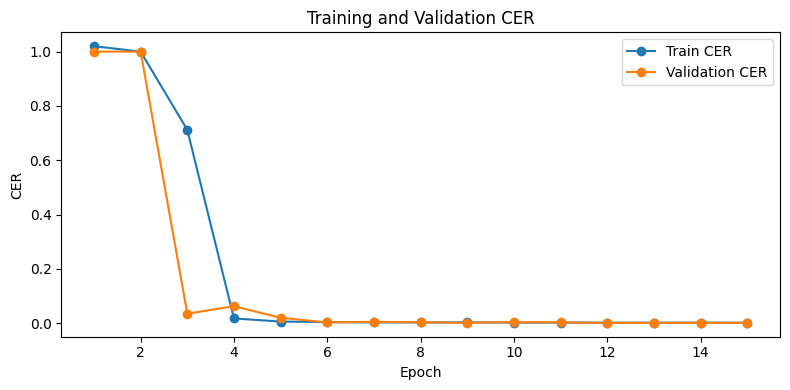

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df["epoch"], history_df["train_cer"], marker="o", label="Train CER")
ax.plot(history_df["epoch"], history_df["val_cer"], marker="o", label="Validation CER")
ax.set_xlabel("Epoch")
ax.set_ylabel("CER")
ax.set_title("Training and Validation CER")
ax.legend()
plt.tight_layout()

## Validation Review

Exact match accuracy is included along with CER because CER is character-level.

In [21]:
payload = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
charset = Charset(payload["alphabet"])

model = CustomCRNN(num_classes=charset.num_classes).to(device)
model.load_state_dict(payload["model"])
model.eval()

validation_predictions = []
validation_targets = []
validation_images = []

with torch.no_grad():
    for batch in tqdm(val_loader, leave=False):
        logits = model(batch["image"].to(device))
        validation_predictions.extend(decode_batch(logits, charset))
        validation_targets.extend(batch["label"])
        validation_images.extend(batch["filename"])

validation_report = pd.DataFrame(
    {
        "image": validation_images,
        "target": validation_targets,
        "prediction": validation_predictions,
    }
)

validation_cer = character_error_rate(validation_predictions, validation_targets)
exact_match = (validation_report["target"] == validation_report["prediction"]).mean()
wrong_samples = (validation_report["target"] != validation_report["prediction"]).sum()

print("Validation CER:", validation_cer)
print("Exact match accuracy:", exact_match)
print("Wrong validation samples:", wrong_samples)

Validation CER: 0.0007916006999416715
Exact match accuracy: 0.9965
Wrong validation samples: 14


In [26]:
validation_report["edit_distance"] = validation_report.apply(
    lambda row: levenshtein(row["prediction"], row["target"]),
    axis=1,
)

validation_report.head(100)

,image,target,prediction,edit_distance
0,train-10650.png,48TADN,48TADN,0
1,train-2041.png,9JEGA6,9JEGA6,0
2,train-8668.png,3JY9FC,3JY9FC,0
3,train-1114.png,GXNHGU,GXNHGU,0
4,train-13902.png,B4238J,B4238J,0
...,...,...,...,...
95,train-12673.png,WSDGZS,WSDGZS,0
96,train-15455.png,AGD29J,AGD29J,0
97,train-14001.png,RZ6JAW,RZ6JAW,0
98,train-18621.png,4QKBAY,4QKBAY,0


## Test Prediction and Submission Generation

In [28]:
test_ds = TestSequenceDataset(test_images, config.img_height, config.img_width)
test_loader = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False)

test_rows = []
model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, leave=False):
        logits = model(batch["image"].to(device))
        predictions = decode_batch(logits, charset)
        test_rows.extend(
            {"image": name, "prediction": pred}
            for name, pred in zip(batch["filename"], predictions)
        )

submission = pd.DataFrame(test_rows)

submission["image_num"] = submission["image"].str.extract(r"test-(\d+)\.png").astype(int)
submission = submission.sort_values("image_num").drop(columns=["image_num"]).reset_index(drop=True)

submission.to_csv(SUBMISSION_PATH, index=False)

print("Submission shape:", submission.shape)
print("Saved submission:", SUBMISSION_PATH)
submission.head()

Submission shape: (5000, 2)
Saved submission: /content/drive/MyDrive/Cig_Ai_open_project/outputs/submission_navya_24119034.csv


,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-2.png,WJ2WNY
3,test-3.png,RFHJD4
4,test-4.png,K7ZUF2


In [ ]:
assert list(submission.columns) == ["image", "prediction"]
assert len(submission) == len(test_images)
assert submission["prediction"].isna().sum() == 0

print("Submission file is valid.")

## Final Output

The final prediction file is saved as:

```text
submission_navya_24119034.csv
```